In [2]:
import pandas as pd
import seaborn as sns
from tqdm import tqdm
import matplotlib.pyplot as plt
from collections import Counter

## Read 3 files Dataset

In [3]:
clickbait_vnm_path = r"..\data\raw\clickbait_dataset_vietnamese.csv"
test_path = r"..\data\raw\test_clickbait.csv"
train_path = r"..\data\raw\train_clickbait.csv"
val_path = r"..\data\raw\val_clickbait.csv"

clickbait_vnm = pd.read_csv(clickbait_vnm_path, encoding='utf-8-sig')
test_df = pd.read_csv(test_path, encoding='utf-8-sig')
train_df = pd.read_csv(train_path, encoding='utf-8-sig')
val_df = pd.read_csv(val_path, encoding='utf-8-sig')

In [4]:
from clickbait_detector.crawl_data import get_article
def crawl_content(urls):
    contents = []
    for url in tqdm(urls, desc="[Processing]"):
        result = get_article(url, crawl_content=True)
        if result is None or "content" not in result:
            contents.append(None)
        else:
            contents.append(result["content"])
    return contents

def get_contents(urls):
    if len(urls) == 0:
        return None
    contents = crawl_content(urls)
    before = len([c for c in contents if c != None])
    print(f"Đã có contents với len: {len(contents)}")
    print(f"Tiến hành chạy chương trình check với {len(urls)-before} url")
    while None in contents:
        tmp = []
        for url, content in zip(urls, contents):
            if content == None:
                tmp.append(url)
        new_contents = crawl_content(tmp)
        if new_contents == 0 or None in new_contents:
            continue
        else:
            for i in range(len(contents)):
                if contents[i] == None:
                    contents[i] = new_contents.pop(0)
    print(f"Chạy check thành công:")
    print(f"Độ dài ban đầu: {before}")
    print(f"Độ dài sau check: {len([c for c in contents if c != None])}")
    return contents


c:\Users\luann\miniconda3\envs\free_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
urls = clickbait_vnm["url"].to_list()
contents = get_contents(urls)
print(len(contents))

[Processing]:   2%|▏         | 56/3414 [00:26<34:41,  1.61it/s]

Lỗi tải: https://tuoitre.vn/vua-ra-tu-ve-toi-hiep-dam-2-thang-sau-lai-tiep-tuc-hiep-dam-tre-em-2025062216055617.htm Response ended prematurely


[Processing]:   2%|▏         | 59/3414 [00:29<40:29,  1.38it/s]

Lỗi tải: https://tuoitre.vn/nha-bao-chien-truong-ngoi-but-giua-dan-bom-ky-4-lam-bao-o-bien-gioi-viet-trung-2025062210180252.htm Response ended prematurely


[Processing]:  39%|███▉      | 1332/3414 [09:21<08:32,  4.06it/s] 

...

Lỗi tải: https://thanhnien.vn/nhan-sac-doi-thuong-cua-tan-hoa-hau-hoan-vu-viet-nam-2025-185250622022605033.htm ('Connection broken: IncompleteRead(0 bytes read, 2 more expected)', IncompleteRead(0 bytes read, 2 more expected))


[Processing]: 100%|██████████| 3414/3414 [25:21<00:00,  2.24it/s]


Đã có contents với len: 3414
Tiến hành chạy chương trình check với 9 url


[Processing]: 100%|██████████| 9/9 [00:04<00:00,  1.84it/s]

Chạy check thành công:
Độ dài ban đầu: 3405
Độ dài sau check: 3414
3414


In [6]:
clickbait_vnm["body_preview"] = contents
clickbait_vnm.head()

,id,url,title,lead_paragraph,category,publish_datetime,source,thumbnail_url,label,body_preview
0,article_0001,https://vnexpress.net/san-bay-vinh-dong-cua-6-...,Sân bay Vinh đóng cửa 6 tháng để nâng cấp,Nghệ AnCảng hàng không Vinh sẽ ngừng hoạt động...,Tin tức tổng hợp,2025-06-23T12:26:00+07:00,VnExpress,data/images/article_0001_image.png,non-clickbait,Nghệ An Cảng hàng không Vinh sẽ ngừng hoạt độn...
1,article_0002,https://vnexpress.net/5-nguoi-thoat-nan-khi-ot...,5 người thoát nạn khi ôtô bị lũ cuốn,Tuyên QuangĐi theo Google Maps song lại được c...,Tin tức tổng hợp,2025-06-23T12:26:00+07:00,VnExpress,data/images/article_0002_image.png,non-clickbait,Tuyên Quang Đi theo Google Maps song lại được ...
2,article_0004,https://vnexpress.net/quy-hoach-9-khu-chuc-nan...,Quy hoạch 9 khu chức năng phía đông TP HCM,9 đồ án quy hoạch 1/2000 được TP Thủ Đức phê d...,Tin tức tổng hợp,2025-06-23T11:56:00+07:00,VnExpress,data/images/article_0004_image.png,non-clickbait,9 đồ án quy hoạch 1/2000 được TP Thủ Đức phê d...
3,article_0006,https://vnexpress.net/tong-bi-thu-trao-quyet-d...,Tổng Bí thư trao quyết định thành lập Cơ quan ...,"Sáng 23/6, Tổng Bí thư Tô Lâm dự và trao quyết...",Tin tức tổng hợp,2025-06-23T11:03:00+07:00,VnExpress,data/images/article_0006_image.png,non-clickbait,"Sáng 23/6, Tổng Bí thư Tô Lâm dự và trao quyết..."
4,article_0010,https://vnexpress.net/quoc-hoi-buoc-vao-tuan-l...,Quốc hội bước vào tuần làm việc cuối cùng của ...,"Tuần cuối kỳ họp 9 (23-27/6), Quốc hội sẽ biểu...",Tin tức tổng hợp,2025-06-23T05:00:00+07:00,VnExpress,data/images/article_0010_image.png,non-clickbait,"Tuần cuối kỳ họp 9 (23-27/6), Quốc hội sẽ biểu..."


In [ ]:
clickbait_vnm.to_csv(r"..\data\raw\final_clickbait_vnm.csv", index=False, encoding="utf-8-sig")

In [7]:
mapping = {"sapo": "lead_paragraph", "final_label": "label"}
train_df.rename(columns=mapping, inplace=True)
val_df.rename(columns=mapping, inplace=True)
test_df.rename(columns=mapping, inplace=True)

In [8]:
print(f"Clickbait Vietnamese columns: {clickbait_vnm.columns.to_list()}")
print(f"Train data columns: {train_df.columns.to_list()}")
print(f"Val data columns: {val_df.columns.to_list()}")
print(f"Test data columns: {test_df.columns.to_list()}")

Clickbait Vietnamese columns: ['id', 'url', 'title', 'lead_paragraph', 'category', 'publish_datetime', 'source', 'thumbnail_url', 'label', 'body_preview']
Train data columns: ['id', 'title', 'lead_paragraph', 'body_preview', 'url', 'source', 'source_category', 'publish_date', 'crawl_timestamp', 'label', 'confidence', 'status', 'rubric_total', 'model_a_label', 'model_b_label', 'model_a_rubric_scores', 'model_b_rubric_scores', 'quality_score', 'quality_breakdown', 'human_verified', 'human_label', 'crawl_method', 'feed_type', 'extraction_success', 'rss_feed', 'body_text', 'model_a_confidence', 'model_a_severity', 'model_a_reason', 'model_a_thought_process', 'model_b_confidence', 'model_b_severity', 'model_b_reason', 'model_b_thought_process', 'severity', 'qa_sample', 'review_status', 'human_rubric_scores', 'human_severity', 'human_notes', 'review_timestamp', 'reviewer_id', 'qa_mismatch', 'split']
Val data columns: ['id', 'title', 'lead_paragraph', 'body_preview', 'url', 'source', 'source_

In [9]:
clickbait_vnm = clickbait_vnm[["url", "title", "lead_paragraph", "label", "body_preview"]]
train_df = train_df[["url", "title", "lead_paragraph", "label", "body_preview"]]
val_df = val_df[["url", "title", "lead_paragraph", "label", "body_preview"]]
test_df = test_df[["url", "title", "lead_paragraph", "label", "body_preview"]]

In [10]:
clickbait_vnm['label'] = clickbait_vnm["label"].map({"non-clickbait": 0, "clickbait": 1})

In [11]:
print(clickbait_vnm.duplicated(subset=["title"]).sum())
print()
print(train_df.duplicated(subset=["title"]).sum())
print()
print(val_df.duplicated(subset=["title"]).sum())
print()
print(test_df.duplicated(subset=["title"]).sum())

0

111

6

40


In [12]:
print(clickbait_vnm.isna().sum())
print()
print(train_df.isna().sum())
print()
print(val_df.isna().sum())
print()
print(test_df.isna().sum())

url               0
title             0
lead_paragraph    3
label             0
body_preview      0
dtype: int64

url               0
title             0
lead_paragraph    0
label             0
body_preview      0
dtype: int64

url               0
title             0
lead_paragraph    0
label             0
body_preview      0
dtype: int64

url               0
title             0
lead_paragraph    0
label             0
body_preview      0
dtype: int64


In [13]:
clickbait_vnm.dropna(subset=["lead_paragraph"], inplace=True)
clickbait_vnm.isna().sum()

url               0
title             0
lead_paragraph    0
label             0
body_preview      0
dtype: int64

In [14]:
def plot_label_dist(labels, ax=None, title=""):
    freq = Counter(labels)
    if ax:
        sns.barplot(x=freq.keys(), y=freq.values(), palette='Set1', ax=ax)
        for p in ax.patches:
            height = p.get_height()
            ax.annotate(f"{int(height)}",
                        xy=(p.get_x() + p.get_width() / 2, height),
                        xytext=(0, 5),
                        textcoords="offset points",
                        ha="center", va="bottom")
        ax.set_title(title)
    else:
        ax = sns.barplot(x=freq.keys(), y=freq.values(), palette='Set1')
        for p in ax.patches:
            height = p.get_height()
            ax.annotate(f"{int(height)}",
                        xy=(p.get_x() + p.get_width() / 2, height),
                        xytext=(0, 5),
                        textcoords="offset points",
                        ha="center", va="bottom")
        plt.title(title)
    

C:\Users\luann\AppData\Local\Temp\ipykernel_28220\27159663.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=freq.keys(), y=freq.values(), palette='Set1', ax=ax)
C:\Users\luann\AppData\Local\Temp\ipykernel_28220\27159663.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=freq.keys(), y=freq.values(), palette='Set1', ax=ax)
C:\Users\luann\AppData\Local\Temp\ipykernel_28220\27159663.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=freq.keys(), y=freq.values(), palette='Set1', ax=ax)
C:\Users\luann\AppData\Local\Temp\ipykernel_28220

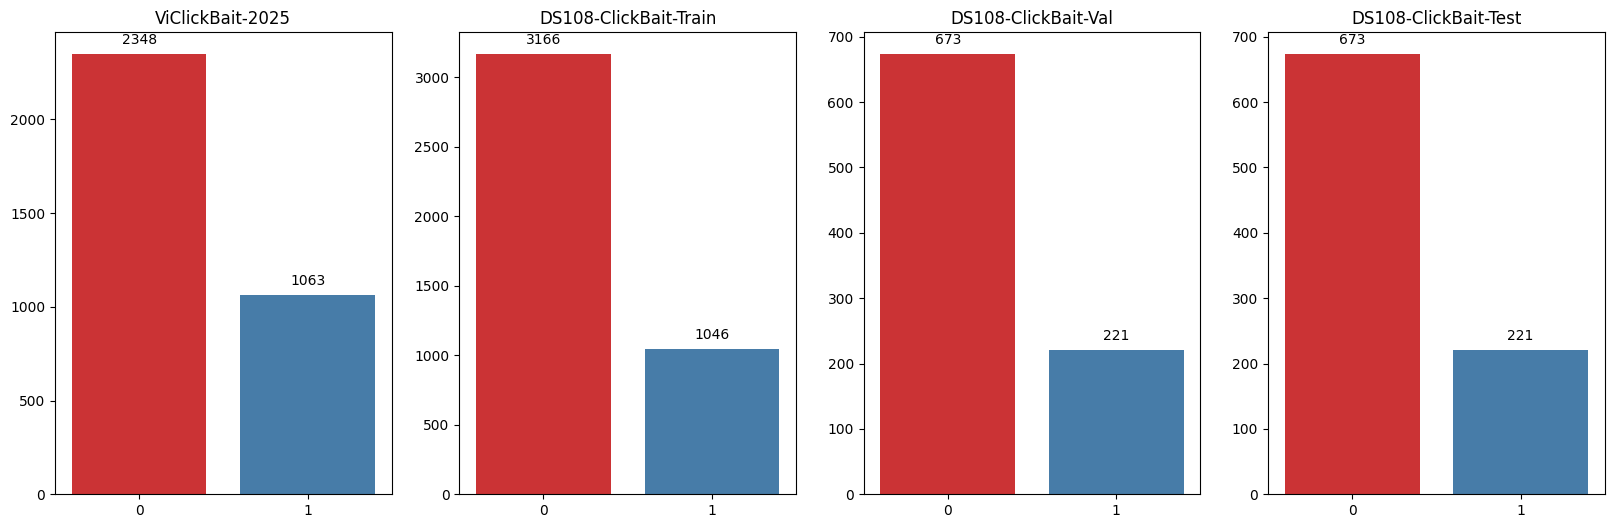

In [15]:
dfs = [clickbait_vnm, train_df, val_df, test_df]
titles = ["ViClickBait-2025", "DS108-ClickBait-Train", "DS108-ClickBait-Val", "DS108-ClickBait-Test"]
fig, ax = plt.subplots(1, 4, figsize=(20, 6))
for i in range(len(dfs)):
    plot_label_dist(dfs[i]["label"], ax=ax[i], title=titles[i])

## Concat Dataset

In [16]:
clickbait_vnm_1 = clickbait_vnm[clickbait_vnm["label"]==1]
val_df_1 = val_df[val_df["label"]==1]
test_df_1 = test_df[test_df["label"]==1]

print(f"Tổng sample có label = 1: {len(clickbait_vnm_1) + len(val_df_1) + len(test_df_1)}")

Tổng sample có label = 1: 1505


In [17]:
sample_1 = pd.concat([clickbait_vnm_1, val_df_1, test_df_1], axis=0, ignore_index=True)
sample_1.head()

,url,title,lead_paragraph,label,body_preview
0,https://tuoitre.vn/yeu-nhau-lam-20250610073453...,Yêu nhau lắm,- Ông có để ý giờ nhiều cặp đôi cứ chia tay là...,1,Tất cả chuyên mục - Ông có để ý giờ nhiều cặp ...
1,https://tuoitre.vn/nha-giau-cung-khoc-20250606...,Nhà giàu cũng khóc,"- Ông nghe chưa, mấy con đường ở ""phố nhà giàu...",1,"Tất cả chuyên mục - Ông nghe chưa, mấy con đườ..."
2,https://tuoitre.vn/nhieu-benh-vien-phia-nam-ng...,Nhiều bệnh viện phía Nam ngừng chụp PET/CT: Cá...,"Chuyện không muốn đã xảy ra, khi nhiều người b...",1,"Tất cả chuyên mục Chuyện không muốn đã xảy ra,..."
3,https://www.saostar.vn/giai-tri/midu-lan-dau-t...,Midu lần đầu tiết lộ bí mật liên quan đến chồn...,"Đây là lần đầu tiên, Midu bật mí về chuyện yêu...",1,TIN HOT Nhật Minh 23/06/2025 - 09:01 (GMT+7) M...
4,https://www.saostar.vn/giai-tri/diep-lam-anh-g...,Diệp Lâm Anh gặp sự cố sức khoẻ,Diệp Lâm Anh gây lo lắng với thông báo mới nhất.,1,TIN HOT Phương Thảo 23/06/2025 - 07:00 (GMT+7)...


In [18]:
sample_1.info()

<class 'pandas.DataFrame'>
RangeIndex: 1505 entries, 0 to 1504
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   url             1505 non-null   str  
 1   title           1505 non-null   str  
 2   lead_paragraph  1505 non-null   str  
 3   label           1505 non-null   int64
 4   body_preview    1505 non-null   str  
dtypes: int64(1), str(4)
memory usage: 6.2 MB


In [19]:
sample_1.duplicated(subset=["title"]).sum()

np.int64(23)

In [20]:
train_full_df = pd.concat([train_df, sample_1], axis=0, ignore_index=True)

In [21]:
train_full_df.duplicated(subset=["title"]).sum()

np.int64(156)

In [22]:
train_full_df.drop_duplicates(subset=["title"], inplace=True)
train_full_df.duplicated(subset=["title"]).sum()

np.int64(0)

C:\Users\luann\AppData\Local\Temp\ipykernel_28220\27159663.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=freq.keys(), y=freq.values(), palette='Set1')


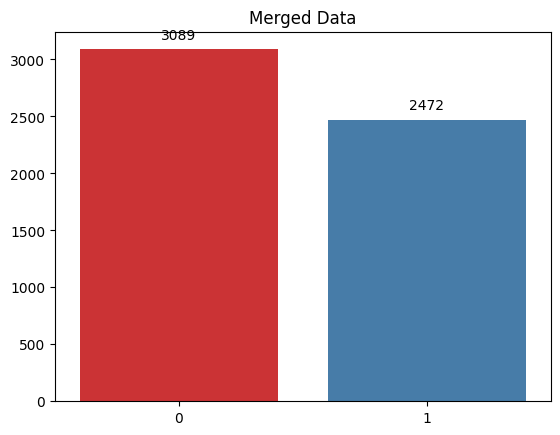

In [23]:
plot_label_dist(train_full_df["label"], title="Merged Data")
plt.show()

In [24]:
article = pd.read_csv(r"..\data\raw\articles2.csv")
article.head()

,url,title,content,lead_paragraph
0,https://ngoisao.vnexpress.net/co-gai-hue-chuon...,Cô gái Huế chuộng dùng dầu để nuôi dưỡng suối ...,Việt Trinh cho biết bổ sung các loại dầu nhiề...,Gửi email cho tác giả
1,https://ngoisao.vnexpress.net/thao-cam-vien-la...,Thảo Cầm Viên làm 'đám cưới' cho hươu cao cổ T...,TP HCMThảo Cầm Viên Sài Gòn sắp tổ chức 'đám ...,Gửi email cho tác giả
2,https://vnexpress.net/con-dao-gianh-vi-tri-so-...,Côn Đảo giành vị trí số một trong top đảo bí ẩ...,Côn Đảo được tạp chí Travel and Leisure xếp vị...,Côn Đảo giành vị trí số một trong top đảo bí ẩ...
3,https://ngoisao.vnexpress.net/a-hau-phuong-anh...,Á hậu Phương Anh: 'Đừng gọi tôi là phu nhân hà...,Á hậu Phương Anh nói cảm thấy ngại khi bị gọi...,Gửi email cho tác giả
4,https://vnexpress.net/chung-cu-hoang-tan-vi-cu...,Chung cư hoang tàn vì cư dân trốn đóng phí dịc...,Hàng nghìn công ty quản lý bất động sản Trung ...,Chung cư hoang tàn vì cư dân trốn đóng phí dịc...


In [25]:
article.isna().sum()

url                 0
title              66
content             4
lead_paragraph    480
dtype: int64

## Combine Data

In [26]:
demo = article.dropna()
demo.isna().sum()

url               0
title             0
content           0
lead_paragraph    0
dtype: int64

In [27]:
with open(r"D:\private\clickbait_detect_proj\notebooks\__pycache__\label.txt") as f:
    label = f.read()
label = label.split(',')
label = [int(i.strip()) for i in label]
print(label)

[0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 

In [28]:
demo["label"] = label

In [29]:
demo.head()

,url,title,content,lead_paragraph,label
0,https://ngoisao.vnexpress.net/co-gai-hue-chuon...,Cô gái Huế chuộng dùng dầu để nuôi dưỡng suối ...,Việt Trinh cho biết bổ sung các loại dầu nhiề...,Gửi email cho tác giả,0
1,https://ngoisao.vnexpress.net/thao-cam-vien-la...,Thảo Cầm Viên làm 'đám cưới' cho hươu cao cổ T...,TP HCMThảo Cầm Viên Sài Gòn sắp tổ chức 'đám ...,Gửi email cho tác giả,0
2,https://vnexpress.net/con-dao-gianh-vi-tri-so-...,Côn Đảo giành vị trí số một trong top đảo bí ẩ...,Côn Đảo được tạp chí Travel and Leisure xếp vị...,Côn Đảo giành vị trí số một trong top đảo bí ẩ...,1
3,https://ngoisao.vnexpress.net/a-hau-phuong-anh...,Á hậu Phương Anh: 'Đừng gọi tôi là phu nhân hà...,Á hậu Phương Anh nói cảm thấy ngại khi bị gọi...,Gửi email cho tác giả,0
4,https://vnexpress.net/chung-cu-hoang-tan-vi-cu...,Chung cư hoang tàn vì cư dân trốn đóng phí dịc...,Hàng nghìn công ty quản lý bất động sản Trung ...,Chung cư hoang tàn vì cư dân trốn đóng phí dịc...,0


C:\Users\luann\AppData\Local\Temp\ipykernel_28220\27159663.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=freq.keys(), y=freq.values(), palette='Set1')


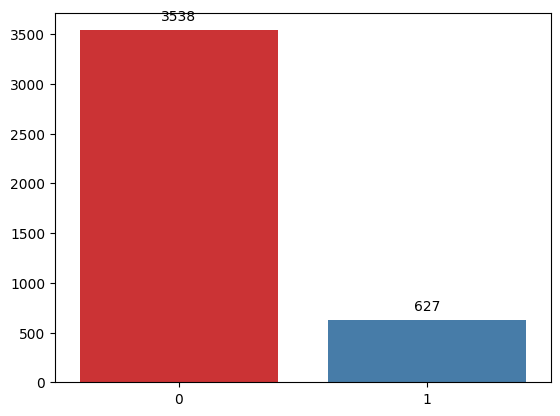

In [30]:
plot_label_dist(demo["label"])

In [31]:
demo_clickbait = demo[demo["label"]==1]

In [32]:
demo_clickbait.rename(columns={"content": "body_preview"}, inplace=True)
demo_clickbait

,url,title,body_preview,lead_paragraph,label
2,https://vnexpress.net/con-dao-gianh-vi-tri-so-...,Côn Đảo giành vị trí số một trong top đảo bí ẩ...,Côn Đảo được tạp chí Travel and Leisure xếp vị...,Côn Đảo giành vị trí số một trong top đảo bí ẩ...,1
6,https://www.saostar.vn/am-nhac/buon-cho-hanh-t...,Buồn cho hành trình khép lại của ca sĩ Thủy Tiên,TIN HOT Thanh Phúc27/06/2026 - 10:00 (GMT+7) ...,Khán giả tiếc nuối cho sự dùng lại của ca sĩ T...,1
12,https://ngoisao.vnexpress.net/ve-sinh-the-nao-...,Vệ sinh thế nào khi 'yêu bằng miệng'?,"Thạc sĩ, bác sĩ Nguyễn Lan Hải tiết lộ biện p...",Gửi email cho tác giả,1
29,https://ngoisao.vnexpress.net/thu-tai-phan-bie...,Thử tài phân biệt thời trang cao cấp và bình d...,Mỗi cặp váy áo hay phụ kiện này có giá chênh ...,Gửi email cho tác giả,1
34,https://vnexpress.net/co-bao-nhieu-con-rua-dan...,Có bao nhiêu con rùa đang 'ẩn mình' trước mắt ...,Ẩn sau bức ảnh là một câu đố thị giác khiến kh...,Có bao nhiêu con rùa đang 'ẩn mình' trước mắt ...,1
...,...,...,...,...,...
4643,https://vnexpress.net/cau-do-que-diem-di-chuye...,Đố bạn di chuyển 2 que diêm để '7 + 6 = 9' đúng?,Nếu bạn đang tìm một câu đố vừa vui vẻ vừa giú...,Đố bạn di chuyển 2 que diêm để '7 + 6 = 9' đúng?,1
4651,https://ngoisao.vnexpress.net/nghe-khach-tay-g...,"Nghe khách Tây gọi tên, bạn có đoán được đây l...",Ẩm thực Việt Nam quen thuộc với người bản địa...,Gửi email cho tác giả,1
4655,https://www.saostar.vn/am-nhac/chau-kiet-luan-...,Châu Kiệt Luân bế con gái 9 tuổi đến Bắc Kinh ...,TIN HOT Hoài Thương26/06/2026 - 17:00 (GMT+7) ...,Châu Kiệt Luân chính thức có mặt tại Bắc Kinh ...,1
4685,https://ngoisao.vnexpress.net/tu-vi-12-con-gia...,"12 con giáp thứ Tư 24/6: Thân lười giao tiếp, ...",Tuổi Thân hôm nay bỗng thấy lười giao tiếp và...,Gửi email cho tác giả,1


C:\Users\luann\AppData\Local\Temp\ipykernel_28220\27159663.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=freq.keys(), y=freq.values(), palette='Set1')


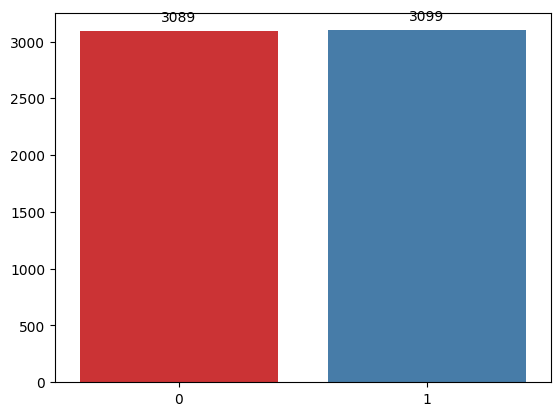

In [33]:
demo_base = pd.concat([train_full_df, demo_clickbait], axis=0, ignore_index=True)
demo_base = demo_base.sample(frac=1).reset_index(drop=True)
plot_label_dist(demo_base["label"])

In [34]:
demo_base.isna().sum()

url               0
title             0
lead_paragraph    0
label             0
body_preview      0
dtype: int64

In [35]:
demo_base.info()

<class 'pandas.DataFrame'>
RangeIndex: 6188 entries, 0 to 6187
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   url             6188 non-null   str  
 1   title           6188 non-null   str  
 2   lead_paragraph  6188 non-null   str  
 3   label           6188 non-null   int64
 4   body_preview    6188 non-null   str  
dtypes: int64(1), str(4)
memory usage: 13.0 MB


In [36]:
demo_base.duplicated(subset="title").sum()

np.int64(2)

In [37]:
demo_base.drop_duplicates(subset="title", inplace=True)

In [38]:
demo_base.shape

(6186, 5)

In [39]:
demo_base.info()

<class 'pandas.DataFrame'>
Index: 6186 entries, 0 to 6187
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   url             6186 non-null   str  
 1   title           6186 non-null   str  
 2   lead_paragraph  6186 non-null   str  
 3   label           6186 non-null   int64
 4   body_preview    6186 non-null   str  
dtypes: int64(1), str(4)
memory usage: 13.0 MB


In [40]:
titles = demo_base["title"].tolist()
lead_p = demo_base["lead_paragraph"].tolist()
content = demo_base["body_preview"].tolist()
new_headlines = []
for t, l, c in zip(titles, lead_p, content):
    new_headline = f"<title> {t} </title> <lead> {l} </lead> <content> {c} </content>"
    new_headlines.append(new_headline)
print(len(new_headlines))

6186


In [41]:
demo_base["title_combined"] = new_headlines 

In [42]:
demo_base.info()

<class 'pandas.DataFrame'>
Index: 6186 entries, 0 to 6187
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   url             6186 non-null   str  
 1   title           6186 non-null   str  
 2   lead_paragraph  6186 non-null   str  
 3   label           6186 non-null   int64
 4   body_preview    6186 non-null   str  
 5   title_combined  6186 non-null   str  
dtypes: int64(1), str(5)
memory usage: 25.5 MB


In [43]:
demo_base.to_csv(r"..\data\processed\combined_dataset.csv", index=False, encoding="utf-8-sig")